# Ligand-Receptor Interaction Correlation (LRIC) - Multi-sample


This notebook extends the cross-PCF and LRIC workflows introduced [in this tutorial](https://github.com/AtheerAS/liana-py/blob/fix/LRIC-analytical/docs/notebooks/LRIC_tutorial.ipynb) to multi-sample spatial analysis. Rather than analysing a single tissue section, the methods are applied across multiple samples to evaluate the consistency and variability of spatial cell-type organisation and ligand–receptor enrichment between sections.

## Environment Setup

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path
from itertools import islice
import copy
from scipy import sparse
import os

import liana as li



import warnings
warnings.filterwarnings("ignore")

## Load Dataset

We use Xenium 5K spatial transcriptomics samples from [McGregor et al., 2025, *Spatial fibroblast niches define Crohn's fistulae*, Nature](https://doi.org/10.1038/s41586-025-09744-y), a subcellular-resolution spatial atlas of intestinal fistulae in Crohn's disease. Samples are annotated by tissue `TYPE` (healthy control, ulcer, fistula) and `LOCATION` (colon, ileum), with cell types provided under `CellAnnotation.Level0`.

The helper below loads one sample: it keeps annotated cells, filters low-count cells/genes, stores raw counts, normalises and log-transforms expression, and subsets to highly variable genes.

In [12]:
def load_crohn_slide(
    sample_id: str,
    data_dir: str = "/g/stegle/aalsayah/repos/data/xenium5k/agne_cd",
    n_top_genes: int = 3000,
    labels_key: str = "CellAnnotation.Level0",
):
    adata = sc.read_h5ad(Path(data_dir) / f"{sample_id}.h5ad")
    adata.obs_names_make_unique()
    # Keep cells with available annotations.
    adata = adata[adata.obs[labels_key].notna()].copy()

    sc.pp.filter_cells(adata, min_counts=3)
    sc.pp.filter_genes(adata, min_counts=3)

    adata.obs[labels_key] = adata.obs[labels_key].astype("category")
    adata.obsm["spatial"] = adata.obs[["x", "y"]].values

    # Preserve raw counts before normalization and log transformation.
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)

    sc.pp.highly_variable_genes(
        adata,
        layer="counts",
        flavor="seurat_v3",
        n_top_genes=min(n_top_genes, adata.n_vars),
        subset=True,
    )
    return adata

In [17]:
sample_ids = ["RUN1_SLIDE1_S3", "RUN1_SLIDE2_S7", "RUN2_SLIDE1_S5", "RUN3_SLIDE1_S4", "RUN3_SLIDE1_S7", "RUN3_SLIDE1_S5"]  # 3 HC vs. 3 FISTULA
data_dir = "/g/stegle/aalsayah/repos/data/xenium5k/agne_cd"

adata_list = [load_crohn_slide(sample_id=sid, data_dir=data_dir) for sid in sample_ids]

## Ligand–Receptor Database

In [13]:
resource = li.rs.select_resource('consensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

4624 LR pairs in resource


,ligand,receptor
0,LGALS9,PTPRC
1,LGALS9,MET
2,LGALS9,CD44
3,LGALS9,LRP1
4,LGALS9,CD47


In [15]:
### set variables
spatial_key = "spatial"
cell_type_key = "CellAnnotation.Level0"
annulus_width = 20
radius_step = 20

In [25]:
sample_ids = ["RUN1_SLIDE1_S3", "RUN1_SLIDE2_S7", "RUN2_SLIDE1_S5", "RUN3_SLIDE1_S4", "RUN3_SLIDE1_S7", "RUN3_SLIDE1_S5"]  # 3 HC vs. 3 FISTULA
data_dir = "/g/stegle/aalsayah/repos/data/xenium5k/agne_cd"

adata_list = [load_crohn_slide(sample_id=sid, data_dir=data_dir) for sid in sample_ids]

## Run cross PCF and LRIC

In [ ]:
for ad in adata_list:
    li.mt.cross_pcf(ad, 
            groupby=cell_type_key,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            key_added="cross_pcf")

    li.mt.lric(
            ad,
            resource=resource,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            expr_prop=0.02,  # NaN-mask ligand/receptor pairs expressed in <2% of cells
            use_raw=False,
            key_added="lric_ag",  #results will be saved under this label in adata.uns
            verbose=True,
        )

    li.mt.lric(
            ad,
            resource=resource,
            groupby=cell_type_key,
            spatial_key=spatial_key,
            max_radius=200,
            radius_step=radius_step,
            annulus_width=annulus_width,
            expr_prop=0.02,  # NaN-mask sender/receiver-celltype pairs expressed in <2% of that celltype
            use_raw=False,
            key_added="lric_ct", #results will be saved under this label in adata.uns
            verbose=True,
        )

Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.


### Cross sample comparisons

#### 1. Summary scores: AUC or contact

**How it works:** We collapse each profile `g(r)` curve to a single number so that "does this spatial relationship differ between conditions?" becomes a plain two-group comparison, one value per sample per feature. <br>

The reduction is applied to `log2 g(r)` and offers two summaries (set by `statistic`):

* `"auc"` (default): the area under `log2 g(r)` integrated across all radii, out to `max_radius`. Summarises the whole radial profile. <br>

* `"contact"`: the mean of log2 g(r) over the innermost `n_contact_bins annuli`, i.e. the direct-neighbour (cell-contact) scale only. <br>

Before comparing, each sample's values are optionally centered (center=True): we subtract that sample's median across all features. This removes per-sample global offsets, so the comparison reflects feature-specific differences rather than a sample's overall co-localization / co-expression level. <br>

We then compare the two groups (e.g. FISTULA vs. HC) per feature with a two-sided Mann-Whitney U test, rank features by effect size — the rank-biserial correlation (signed: positive means higher in the first group), and adjust p-values across features with the Benjamini-Hochberg FDR.

> _Note regarding sample size_:  This example has only three samples per group. With `n = 3 vs. 3`, the smallest attainable two-sided Mann-Whitney p-value is `0.10` (reached when the two groups are perfectly separated), so no single feature can cross a conventional `p < 0.05` threshold and all BH-FDR values stay `≥ ~0.1`. The comparison is therefore exploratory: use the rank-biserial effect size to prioritise features and treat the hits as hypothesis-generating rather than confirmatory.

In [27]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# ---- configuration ---------------------------------------------------------
G_FLOOR      = 0.05                      # floor on g(r) before log2 (keeps empty/depleted bins finite)
HALF_ANNULUS = annulus_width / 2         # inner-edge radius -> annulus centre
OBS          = dict(sample="SAMPLE", type="TYPE")   # .obs columns: sample id, group label
GROUP_COLORS = {"FISTULA": "#009E73", "HC": "#6A51A3"}
TOP_N        = 5

def _log2g(curve):
    """log2 g(r), g floored at G_FLOOR to keep empty/depleted bins finite."""
    return np.log2(np.maximum(np.asarray(curve, float), G_FLOOR))

def _iter_features(adata, modality):
    """Yield (feature_key, g(r) profile) for every feature in adata.uns[modality]."""
    d = adata.uns[modality]; r = np.asarray(d["radii"], float)
    if modality == "cross_pcf":                       # symmetric: emit each unordered pair once
        seen = set()
        for k, c in d["results"].items():
            if frozenset(k) not in seen and not seen.add(frozenset(k)):
                yield k, np.asarray(c, float).ravel()
    elif modality == "lric_ag":
        M = np.asarray(d["lric"], float); M = M if M.shape[0] == r.size else M.T
        for j, lr in enumerate(d["pair_names"]): yield lr, M[:, j]
    elif modality == "lric_ct":
        for k, a in d["results"].items():
            A = np.asarray(a, float); A = A if A.shape[0] == r.size else A.T
            for j, lr in enumerate(d["pair_names"]): yield (k, lr), A[:, j]
    else:
        raise ValueError(f"unknown modality {modality!r}")

def _feature_label(feat, modality):
    if modality == "cross_pcf": return f"{feat[0]} ↔ {feat[1]}"
    if modality == "lric_ag":   return feat.replace("^", " → ")
    (a, b), lr = feat;          return f"{a} → {b}\n{lr.replace('^', ' → ')}"

def _summarize_curve(curve, radii, statistic="auc", n_contact_bins=1):
    """Reduce g(r) to a scalar (log2 units): 'auc' over all radii, or 'contact' over innermost bins."""
    y = _log2g(curve)
    if statistic == "contact":
        w = y[:n_contact_bins]; return np.nanmean(w) if np.isfinite(w).any() else np.nan
    if statistic == "auc":
        x = np.asarray(radii, float) + HALF_ANNULUS; m = np.isfinite(x) & np.isfinite(y)
        return np.trapezoid(y[m], x[m]) if m.sum() >= 3 else np.nan
    raise ValueError(f"statistic must be 'auc' or 'contact', got {statistic!r}")

def feature_table(adata_list, modality, statistic="auc", n_contact_bins=1, center=True):
    """(sample, feature) summary table. statistic: 'auc' (all radii) or 'contact' (innermost
    n_contact_bins). center: subtract each sample's median across features (removes sample-level offset)."""
    rows = []
    for ad in adata_list:
        meta = {n: str(ad.obs[c].iloc[0]) for n, c in OBS.items()}
        radii = np.asarray(ad.uns[modality]["radii"], float)
        for key, curve in _iter_features(ad, modality):
            rows.append({**meta, "feature": key, "summary": _summarize_curve(curve, radii, statistic, n_contact_bins)})
    df = pd.DataFrame(rows)
    if center: df["summary"] = df.groupby("sample")["summary"].transform(lambda s: s - s.median())
    return df

def compare_groups(df, a="FISTULA", b="HC", min_n=2):
    """Feature-wise Mann-Whitney (a vs b), rank-biserial effect size, BH-FDR; sorted by rb."""
    out = []
    for feat, g in df.groupby("feature", sort=False):
        xa = g.loc[g["type"] == a, "summary"].dropna().values
        xb = g.loc[g["type"] == b, "summary"].dropna().values
        if len(xa) < min_n or len(xb) < min_n: continue
        u = mannwhitneyu(xa, xb, alternative="two-sided")
        out.append(dict(feature=feat, rb=2*u.statistic/(len(xa)*len(xb)) - 1, p=u.pvalue,
                        **{f"mean_{a}": xa.mean(), f"mean_{b}": xb.mean(), f"n_{a}": len(xa), f"n_{b}": len(xb)}))
    res = pd.DataFrame(out)
    if len(res):
        res["padj"] = multipletests(res["p"], method="fdr_bh")[1]
        res["diff"] = res[f"mean_{a}"] - res[f"mean_{b}"]
        res = res.sort_values(["rb", "diff"], ascending=False).reset_index(drop=True)
    return res

def plot_top_features(df, res, modality, top_n=TOP_N, a="FISTULA", b="HC", seed=0):
    """Boxplots of the top-top_n features; one point per sample."""
    top = res.head(top_n); ncol = min(5, len(top)); nrow = int(np.ceil(len(top)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(3.2*ncol, 3.5*nrow), squeeze=False)
    rng = np.random.default_rng(seed)
    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
        sub = df[df.feature == row.feature]
        data = [sub.loc[sub["type"] == grp, "summary"].dropna().values for grp in (a, b)]
        bp = ax.boxplot(data, tick_labels=[a, b], widths=.5, showfliers=False, patch_artist=True)
        for patch, grp in zip(bp["boxes"], (a, b)): patch.set_facecolor(GROUP_COLORS[grp]); patch.set_alpha(.25)
        for med in bp["medians"]: med.set_color("black")
        for x, (grp, v) in enumerate(zip((a, b), data), 1):
            ax.scatter(x + rng.uniform(-.08, .08, v.size), v, s=45, zorder=3, marker="o",
                       color=GROUP_COLORS[grp], edgecolor="black", lw=.4)
        ax.axhline(0, color="grey", ls="--", lw=.8)
        ax.set_title(f"{_feature_label(row.feature, modality)}\nrb={row.rb:.2f}  p={row.p:.2g}  padj={row.padj:.2g}", fontsize=8)
        ax.set_ylabel("log2 g(r) summary", fontsize=8); ax.tick_params(labelsize=8)
    for ax in axes.ravel()[len(top):]: ax.set_visible(False)
    handles = [plt.Line2D([0],[0], marker="o", ls="none", mfc=GROUP_COLORS[grp], mec="black", label=grp) for grp in (a, b)]
    fig.legend(handles=handles, title=OBS["type"], loc="upper right", bbox_to_anchor=(1, 1), frameon=False)
    fig.suptitle(f"{modality}: top {len(top)} features ({a} vs {b})", y=1.02)
    fig.tight_layout(rect=[0, 0, .9, 1]); return fig

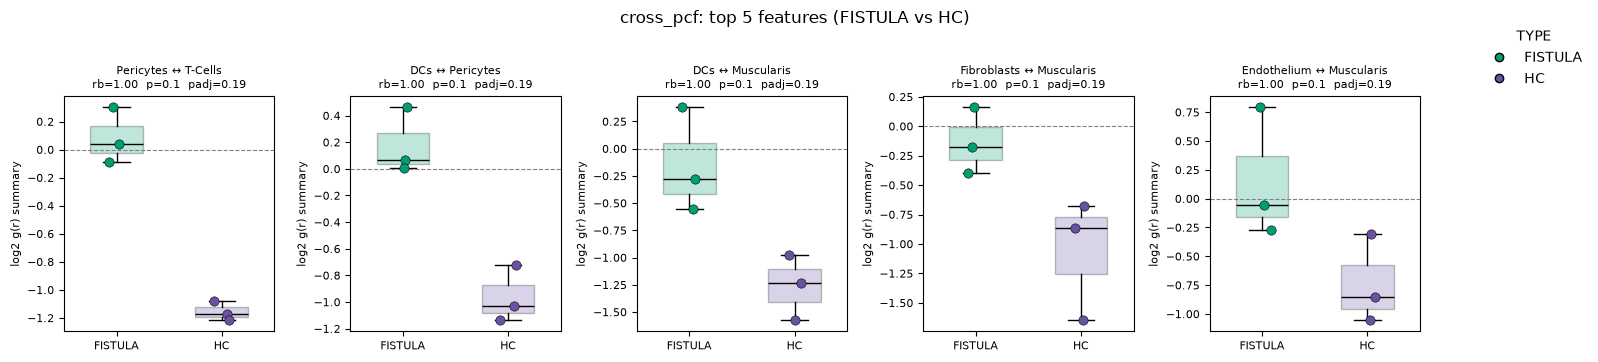

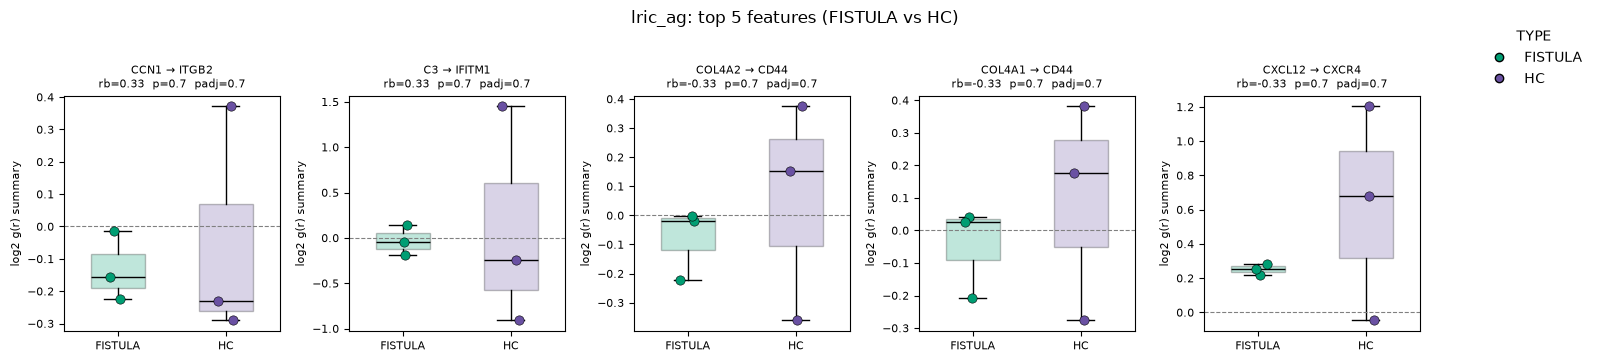

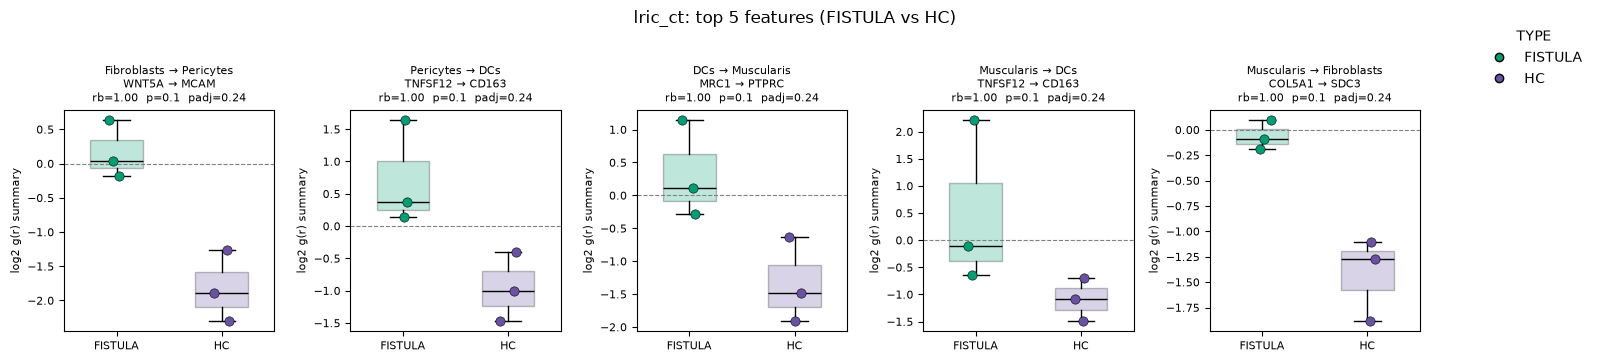

In [28]:
for modality in ("cross_pcf", "lric_ag", "lric_ct"):
    # short-range (contact ring only)
    tbl = feature_table(adata_list, modality, statistic="contact", n_contact_bins=1)
    # full radial range (default)
    #tbl = feature_table(adata_list, modality)                      # statistic="auc"

    res = compare_groups(tbl, a="FISTULA", b="HC", min_n=3)
    plot_top_features(tbl, res, modality); plt.show()

#### 2. Summary score: divergence

Summary score 1 collapses each curve to a single number (its AUC, or the short-range contact value), simple, but it discards where along r the two groups diverge, and opposite-signed differences at different radii can cancel out.
<br>

 Summary score 2 instead compares the **full curves**: for each feature it takes the group-mean log2 g(r) curves for FISTULA and HC, measures the area between them (`divergence`, an L1 distance in curve-space) and the radius of maximal divergence (`r_star`), and tests significance by label permutation (shuffling the FISTULA/HC labels across samples and recomputing divergence) rather than a rank test. This is more sensitive to differences concentrated at a specific distance.

Below, the shaded area between the group-mean curves visualises `divergence` directly; the dotted vertical line marks `r_star`, the radius of strongest divergence.

In [31]:
import itertools

def compare_curves(adata_list, modality, a="FISTULA", b="HC", center=True, max_perm=2000, seed=0):
    """Curve-level group comparison of log2 g(r) profiles.

    divergence : L1 area between the two group-mean curves.
    r_star     : radius of maximum divergence; `direction` is the sign of the difference there.
    p          : label-permutation p-value on the divergence (bounded below by
                 2 / C(n_a + n_b, n_a) when permutations are enumerated exactly).
    center     : subtract each sample's per-radius feature-median curve before forming the
                 group means, removing sample-level, distance-dependent offsets.
    """
    curves, labels, x = {}, [], None
    for ad in adata_list:
        grp = str(ad.obs[OBS["type"]].iloc[0])
        if grp not in (a, b): continue
        x = np.asarray(ad.uns[modality]["radii"], float) + HALF_ANNULUS; labels.append(grp)
        keys, ys = zip(*[(k, _log2g(c)) for k, c in _iter_features(ad, modality)])
        Y = np.vstack(ys)
        if center: Y = Y - np.nanmedian(Y, axis=0, keepdims=True)   # per-sample, per-radius baseline
        for k, y in zip(keys, Y): curves.setdefault(k, []).append(y)

    labels = np.asarray(labels); n = len(labels); m0 = labels == a
    na, nb = int(m0.sum()), int(n - m0.sum())
    splits = list(itertools.combinations(range(n), na))
    if len(splits) > max_perm:
        rng = np.random.default_rng(seed)
        splits = [tuple(rng.choice(n, na, replace=False)) for _ in range(max_perm)]
    M = np.full((len(splits), n), -1.0/nb)
    for i, s in enumerate(splits): M[i, list(s)] = 1.0/na

    rows = []
    for k, ys in curves.items():
        if len(ys) != n: continue
        Y = np.vstack(ys)
        if not np.isfinite(Y).all(): continue          # keep only features observed in every sample
        d = Y[m0].mean(0) - Y[~m0].mean(0); T = np.trapezoid(np.abs(d), x); j = int(np.argmax(np.abs(d)))
        rows.append(dict(feature=k, divergence=float(T), r_star=float(x[j]),
                         direction="up" if d[j] > 0 else "down",
                         p=float(np.mean(np.trapezoid(np.abs(M @ Y), x, axis=1) >= T*(1-1e-9)))))
    res = pd.DataFrame(rows)
    res["padj"] = multipletests(res["p"], method="fdr_bh")[1]
    return res.sort_values("divergence", ascending=False).reset_index(drop=True)


def plot_divergence(adata_list, res, modality, top_n=TOP_N, a="FISTULA", b="HC", center=True, ncol=3):
    """Group mean ± SD curves; grey band between the means = divergence, dotted line = r_star."""
    top = res.head(top_n); want = set(top.feature); gc, x = {}, None
    for ad in adata_list:
        grp = str(ad.obs[OBS["type"]].iloc[0])
        if grp not in (a, b): continue
        x = np.asarray(ad.uns[modality]["radii"], float) + HALF_ANNULUS
        keys, ys = zip(*[(k, _log2g(c)) for k, c in _iter_features(ad, modality)])
        Y = np.vstack(ys)
        if center: Y = Y - np.nanmedian(Y, axis=0, keepdims=True)   # same centering as compare_curves
        for k, y in zip(keys, Y):
            if k in want: gc.setdefault(k, {}).setdefault(grp, []).append(y)

    ncol = min(ncol, len(top)); nrow = int(np.ceil(len(top)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.4*nrow), squeeze=False)
    for ax, (_, row) in zip(axes.ravel(), top.iterrows()):
        m = {g: np.vstack(v) for g, v in gc[row.feature].items()}
        ax.fill_between(x, m[a].mean(0), m[b].mean(0), color="0.6", alpha=.35, lw=0)
        for g in (a, b):
            mu, sd = m[g].mean(0), m[g].std(0)
            ax.fill_between(x, mu-sd, mu+sd, color=GROUP_COLORS[g], alpha=.15, lw=0)
            ax.plot(x, mu, color=GROUP_COLORS[g], lw=2)
        ax.axvline(row.r_star, color="black", ls=":", lw=1)
        ax.axhline(0, color="grey", ls="--", lw=.8)
        ax.set_title(f"{_feature_label(row.feature, modality)}\ndiv={row['divergence']:.1f}  "
                     f"r*={row.r_star:.0f}µm  p={row.p:.2g}", fontsize=8)
        ax.set_xlabel("radius r (µm)", fontsize=8)
        ax.set_ylabel("centered log2 g(r)" if center else "log2 g(r)", fontsize=8)
        ax.tick_params(labelsize=8)
    for ax in axes.ravel()[len(top):]: ax.set_visible(False)
    h = [plt.Line2D([0],[0], color=GROUP_COLORS[g], lw=2, label=f"{g} (mean±SD)") for g in (a, b)]
    h += [plt.Rectangle((0,0),1,1, color="0.6", alpha=.35, label="divergence")]
    fig.legend(handles=h, loc="upper right", bbox_to_anchor=(1,1), frameon=False, fontsize=8)
    fig.suptitle(f"{modality}: top {len(top)} by divergence ({a} vs {b})", y=1.02)
    fig.tight_layout(rect=[0,0,.88,1]); plt.show()

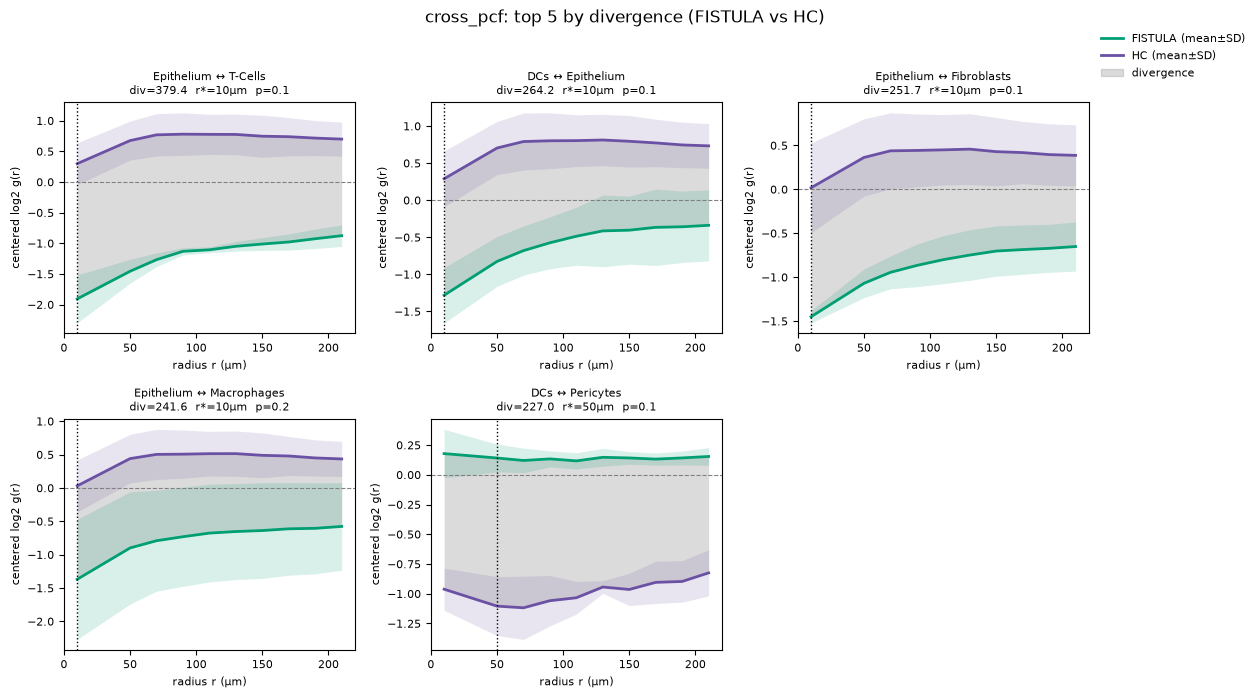

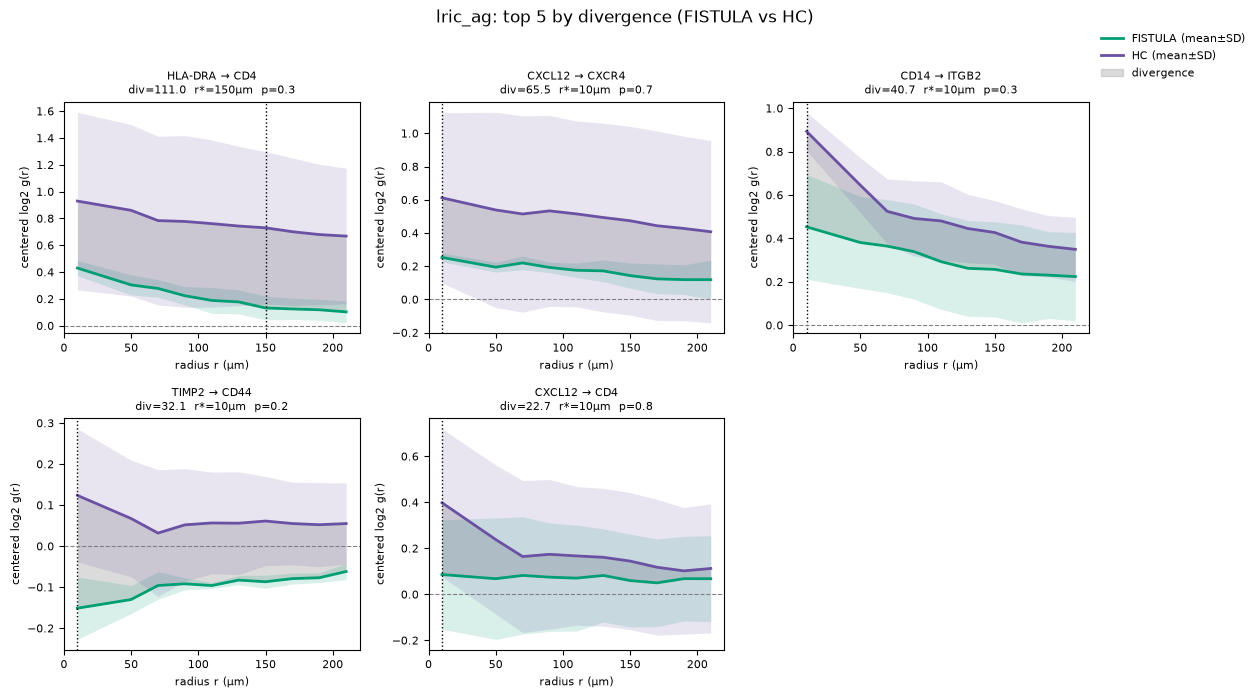

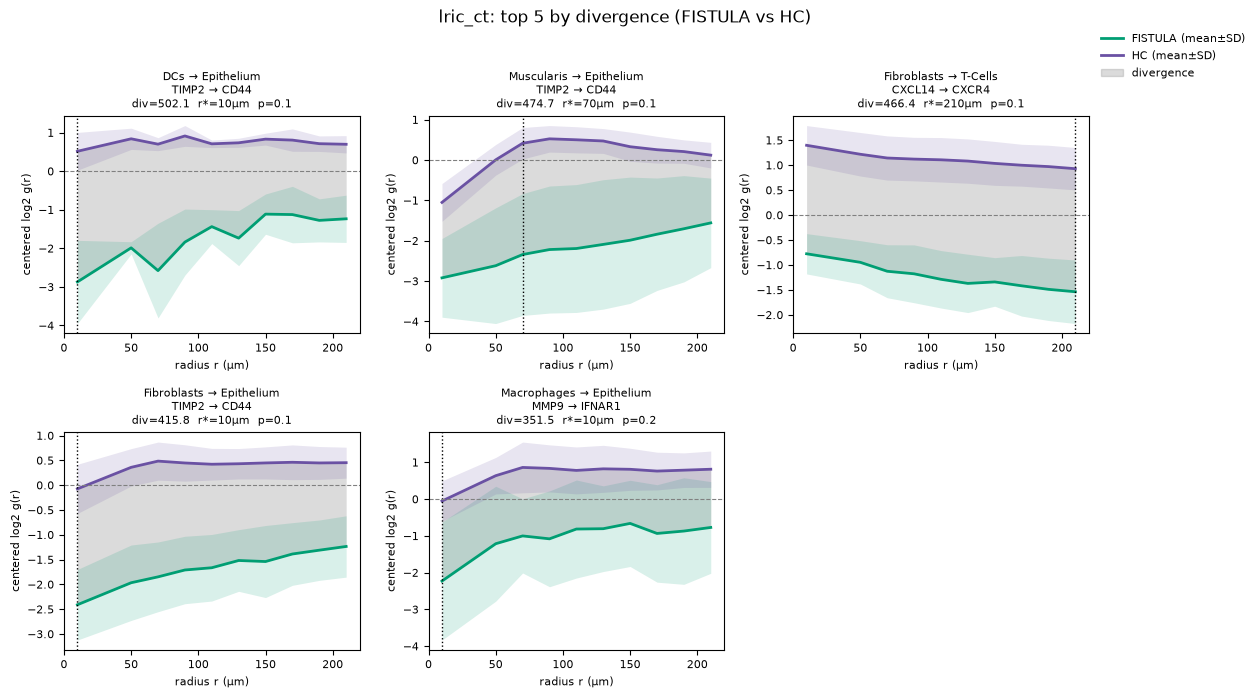

In [32]:
for modality in ("cross_pcf", "lric_ag", "lric_ct"):
    res = compare_curves(adata_list, modality, a="FISTULA", b="HC")
    plot_divergence(adata_list, res, modality)

---

<div style="border:2px solid #790e0eff; background-color:#e3f2fd; padding:12px; border-radius:8px; font-size:1.1em; margin:10px 0;">
<strong>Note:</strong> This tutorial is part of an ongoing <b>LIANA+</b> extension (Alsayah et al., in prep). Feedback welcome!
</div>